In [4]:
import numpy as np
import numpy.random as random
import matplotlib.pyplot as plt
import cc3d 

In [5]:
def search(grid,test_grid,cluster,count):
    if grid[cluster[-1]] == 1:
        count += 1
        grid[cluster[-1]] = 0
        for k in range(len(cluster)):
            test_grid[cluster[k]] = count
        #print(count)
        #print(test_grid[1:-1,1:-1])
        
        m,n = cluster[-1]

        if grid[m,n+1] == 1:
            cluster.append((m,n+1))
            count = search(grid,test_grid,cluster,count)
        if grid[m,n-1] == 1:
            cluster.append((m,n-1))
            count = search(grid,test_grid,cluster,count)
        if grid[m+1,n] == 1:
            cluster.append((m+1,n))
            count = search(grid,test_grid,cluster,count)
        if grid[m-1,n] == 1:
            cluster.append((m-1,n))
            count = search(grid,test_grid,cluster,count)
    return count


In [6]:
p=0.57
N_site = 100
grid = random.choice(2,p=[1-p,p],size=(N_site,N_site))

used_grid = np.pad(grid,(1,1),constant_values=(0,0))
test_grid=np.zeros((N_site+2,N_site+2))

for i in range(1,N_site+1):
    for j in range(1,N_site+1):
        cluster = [(i,j)]
        count = 0
        search(used_grid,test_grid,cluster,count)

# print(test_grid[1:-1,1:-1])

cluster_size = np.arange(1,int(np.max(test_grid)+1))
cluster_size_count = []

for i in range(1,int(np.max(test_grid)+1)):
    cluster_size_count.append(int(np.bincount(test_grid.astype(int).flatten())[i]/i))

cluster_to_bins = np.repeat(cluster_size,cluster_size_count)


In [7]:
def search_label(grid,label_grid,m,n,label):
    if grid[m,n] == 1:
        grid[m,n] = 0
        label_grid[m,n] = label

        if grid[m,n+1] == 1:
            search_label(grid,label_grid,m,n+1,label)
        if grid[m,n-1] == 1:
            search_label(grid,label_grid,m,n-1,label)
        if grid[m+1,n] == 1:
            search_label(grid,label_grid,m+1,n,label)
        if grid[m-1,n] == 1:
            search_label(grid,label_grid,m-1,n,label)

def label_to_data(label_grid):
    sizes = np.bincount(label_grid.astype(int).flatten())[1:]
    sizes_number = np.bincount(sizes)[1:]
    size_grid = np.zeros(np.shape(label_grid))
    for i in range(1,int(np.max(label_grid)+1)):
        size_grid[label_grid==i]=np.bincount(label_grid.astype(int).flatten())[i]
    return sizes,sizes_number,size_grid

In [8]:
def percolation(p,N_site):
    grid = random.choice(2,p=[1-p,p],size=(N_site,N_site))

    # print(grid)

    used_grid = np.pad(grid,(1,1),constant_values=(0,0))
    label_grid=np.zeros((N_site+2,N_site+2))
    label = 0
    for i in range(1,N_site+1):
        for j in range(1,N_site+1):
            if used_grid[i,j]==1:
                label += 1
            search_label(used_grid,label_grid,i,j,label)


    #print(label_grid[1:-1,1:-1])
    sizes,sizes_number,size_grid = label_to_data(label_grid[1:-1,1:-1])
    return sizes,sizes_number,size_grid

In [9]:
p=0.59
N_site = 100
sizes,sizes_number,size_grid = percolation(p,N_site)
size_axis=np.arange(1,int(max(sizes)+1))


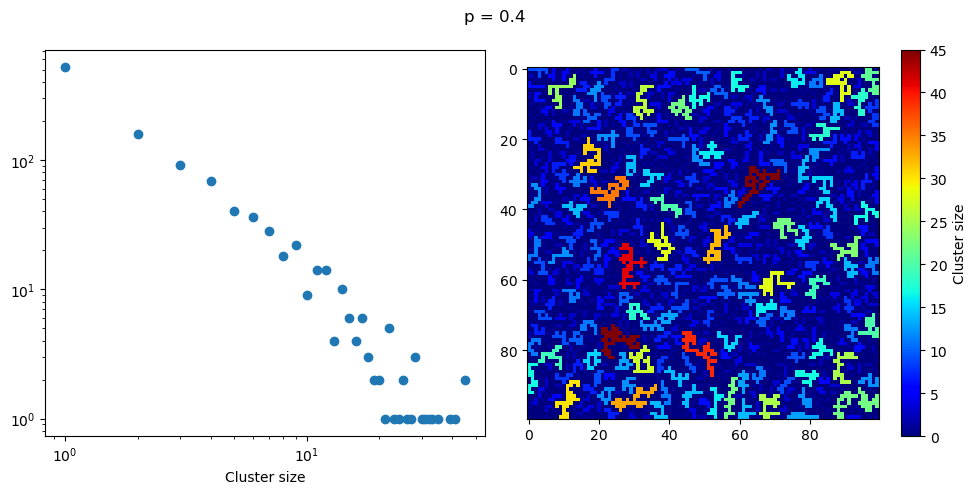

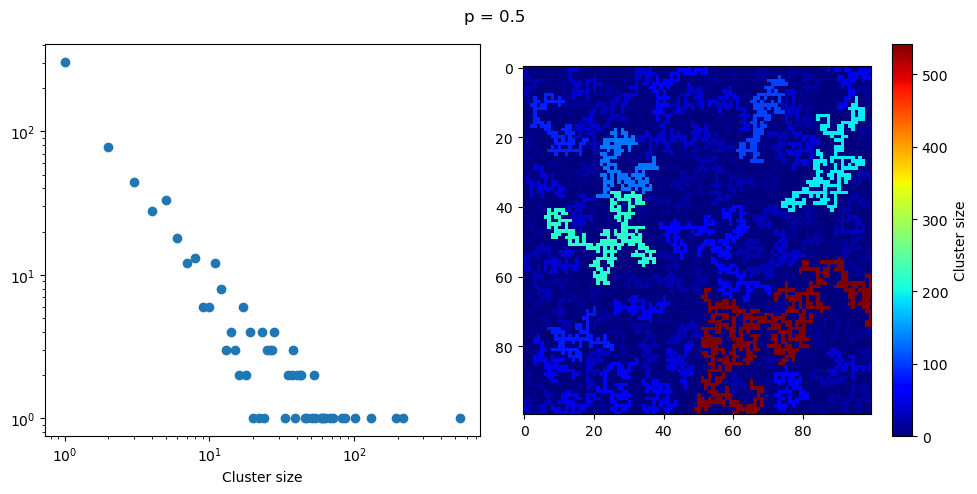

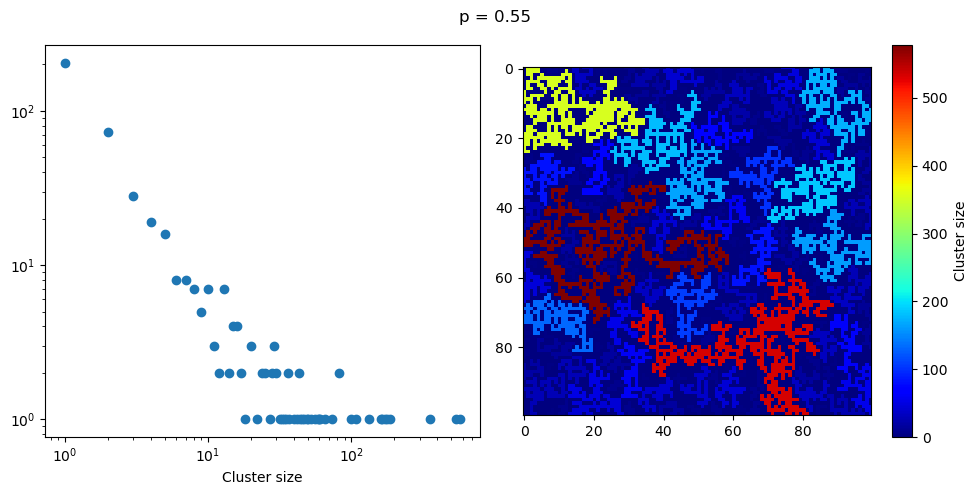

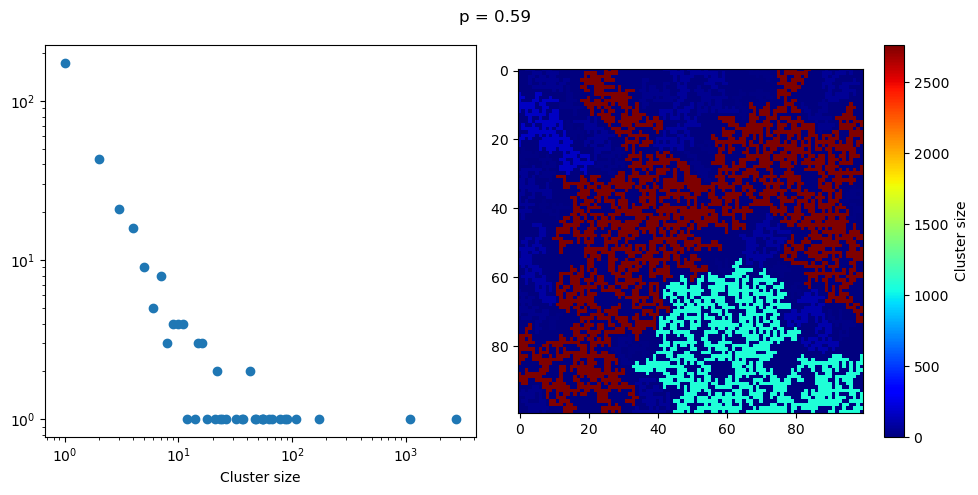

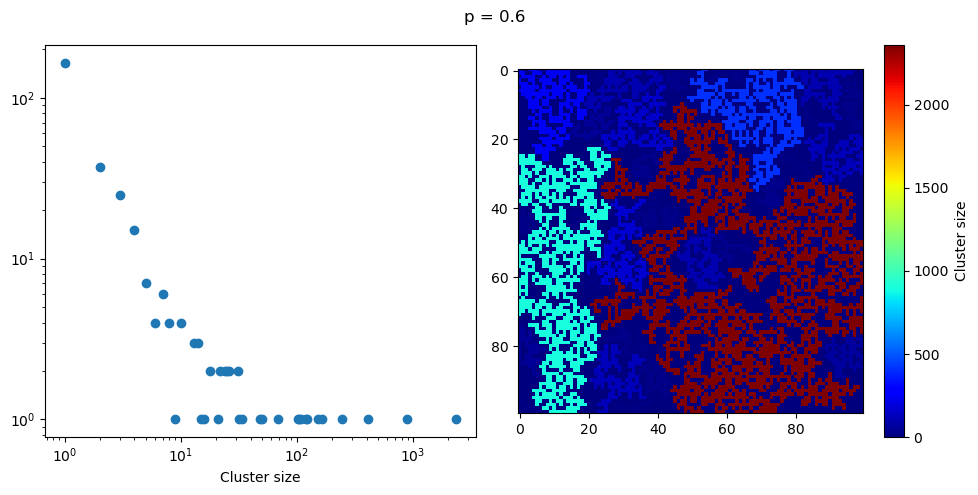

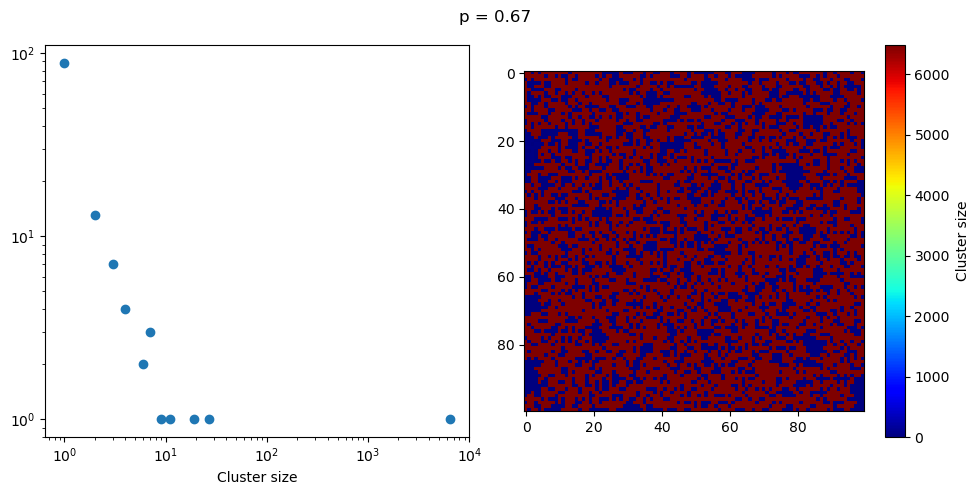

In [121]:
random.seed(7007)
p_list = [0.4,0.5,0.55,0.59,0.6,0.67]
size_minus_mean_list = []
for ii,p in enumerate(p_list):
    N_site = 100
    sizes,sizes_number,size_grid = percolation(p,N_site)
    size_axis=np.arange(1,int(max(sizes)+1))
    fig,(ax1,ax2)=plt.subplots(1,2,figsize=(10,5))

    ax1.scatter(size_axis,sizes_number)
    ax1.loglog()
    ax1.set_xlabel("Cluster size")
    color = ax2.imshow(size_grid,cmap="jet",interpolation="none",aspect="equal")
    fig.colorbar(color,ax=ax2,label="Cluster size")
    fig.suptitle("p = "+str(p))
    fig.tight_layout()
    plt.show()

    size_minus_mean = max(sizes)-np.mean(sizes)
    size_minus_mean_list.append(size_minus_mean/(N_site)**2)

In [ ]:
def percolation_cc3d(p,N_site):
    grid = random.choice(2,p=[1-p,p],size=(N_site,N_site))
    # print(np.sum(grid)/(N_site**2))
    label_grid = cc3d.connected_components(grid,connectivity=4,periodic_boundary=False)
    sizes,sizes_number,size_grid = label_to_data(label_grid)
    return sizes,sizes_number,size_grid

0.49970408163265306


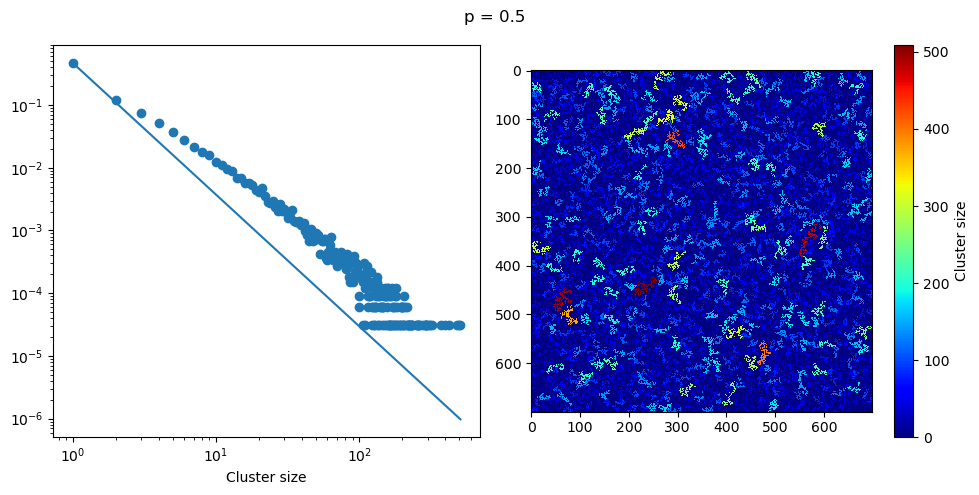

0.550634693877551


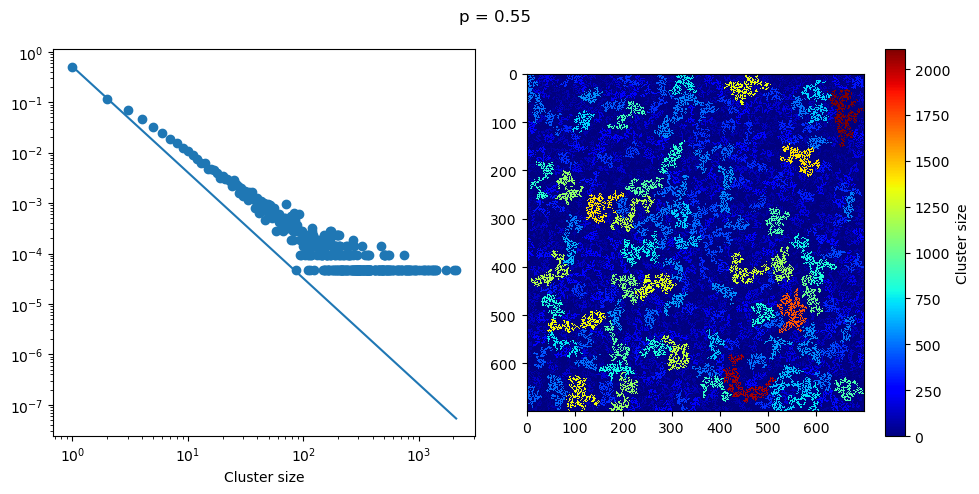

0.5920938775510204


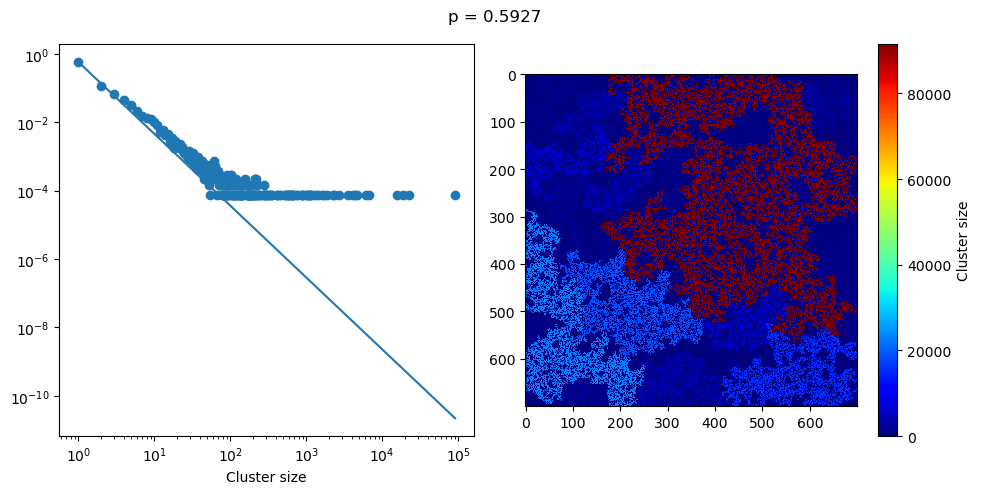

0.5993571428571428


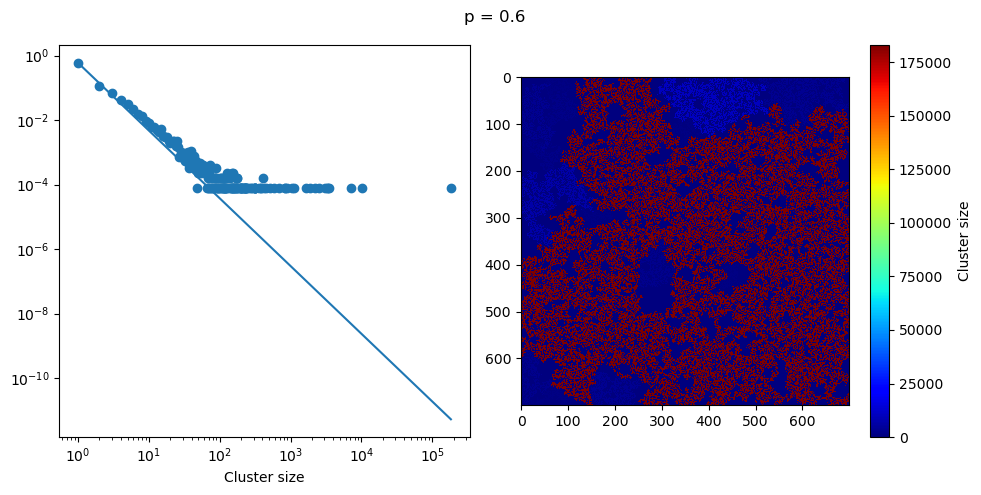

0.6295


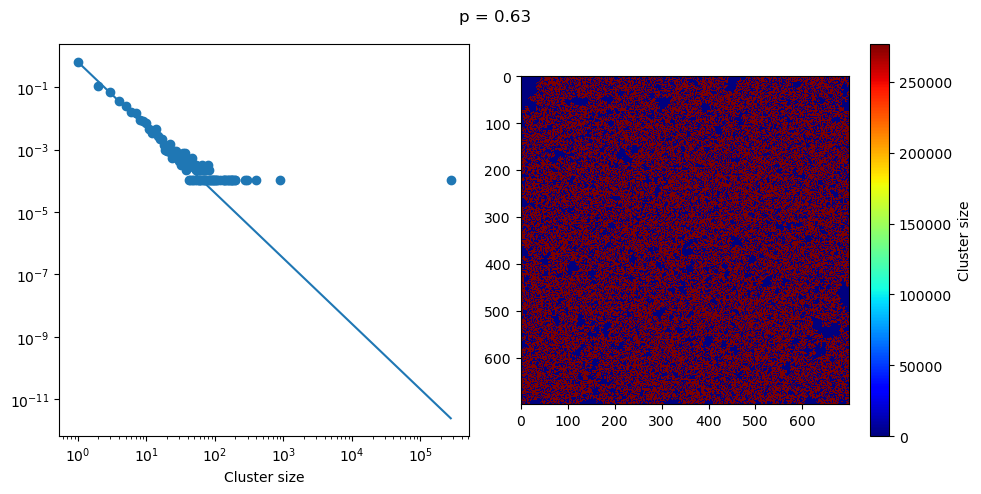

In [27]:
# random.seed(7007)
p_list = [0.5,0.55,0.5927,0.6,0.63]
# p_list = [0.5]
size_minus_mean_list = []
for ii,p in enumerate(p_list):
    N_site = 700
    sizes,sizes_number,size_grid = percolation_cc3d(p,N_site)
    size_axis=np.arange(1,int(max(sizes)+1))
    fig,(ax1,ax2)=plt.subplots(1,2,figsize=(10,5))


    n = size_axis**(-2.1)
    n = n/n[0]*sizes_number[0]/(np.sum(sizes_number))
    ax1.plot(size_axis,n)

   # print(sizes)
   #print(np.histogram(sizes,bins=np.arange(1,max(sizes)+2)))
    mask = sizes_number!=0
    # print(mask)
    #print(sizes_number)
    ax1.scatter(size_axis[mask],sizes_number[mask]/(np.sum(sizes_number)))
    ax1.loglog()
    ax1.set_xlabel("Cluster size")
    color = ax2.imshow(size_grid,cmap="jet",interpolation="none",aspect="equal")
    fig.colorbar(color,ax=ax2,label="Cluster size")
    fig.suptitle("p = "+str(p))
    fig.tight_layout()
    plt.show()

    size_minus_mean = max(sizes)-np.mean(sizes)
    size_minus_mean_list.append(size_minus_mean/(N_site)**2)


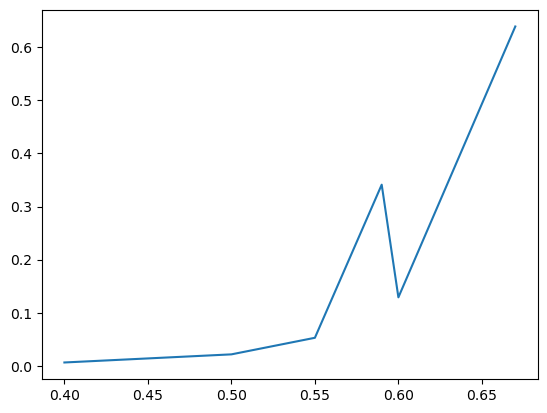

In [118]:
plt.plot(p_list,size_minus_mean_list)